# Lab Instructions

You have been hired by James Cameron to create profiles of two characters for a reboot of the Titanic Movie: one that is most likely to survive the sinking and one that is least likely to survive.  Mr. Cameron wants this reboot to be as historically accurate as possible, so your profile of each character should be backed up with data and visualizations.

Each character profile should include information on their:
* Age, fare
* Sex
* Passenger class
* Travel companions (including both parents/children and siblings/spouse)
* Port of departure (indicated by the Embarked feature in the dataset)

For quantitative features like `Age` and `Fare`, you will need to use the `.loc` method we learned in class (or something similar) to place individuals in categories.  How you choose to do this is up to you, but make sure you explain your reasoning.

You should include at least one visualization for each element of the character profile (age, sex, passenger class, etc.) as evidence.

After you have developed your two character profiles, use your Pandas data wrangling skills to identify at least one real passenger in the dataset that fits each profile.  Print out the names of these individuals.  Look them up in [Encyclopeida Titanica](https://www.encyclopedia-titanica.org/) (or a similar resource).  

Tell Mr. Cameron at least one thing about the real passengers who fit your two character profiles that you learned from an external resource.  You need one interesting fact about a person who fits the profile of "most likely to survive" and one interesting fact about a person who fits the profile of "least likely to surivive".  



In [1]:
import pandas as pd

df = pd.read_csv('titanic_passengers.csv')

df.head(25)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [3]:
df['Fare'].describe()

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64

In [2]:
import pandas as pd

df = pd.read_csv('titanic_passengers.csv')
df.head(25)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [3]:
print("Survival rate by Sex:")
print(df.groupby('Sex')['Survived'].mean())

print("\nSurvival rate by Pclass:")
print(df.groupby('Pclass')['Survived'].mean())

print("\nSurvival rate by Embarked:")
print(df.groupby('Embarked')['Survived'].mean())

Survival rate by Sex:
Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

Survival rate by Pclass:
Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

Survival rate by Embarked:
Embarked
C    0.553571
Q    0.389610
S    0.336957
Name: Survived, dtype: float64


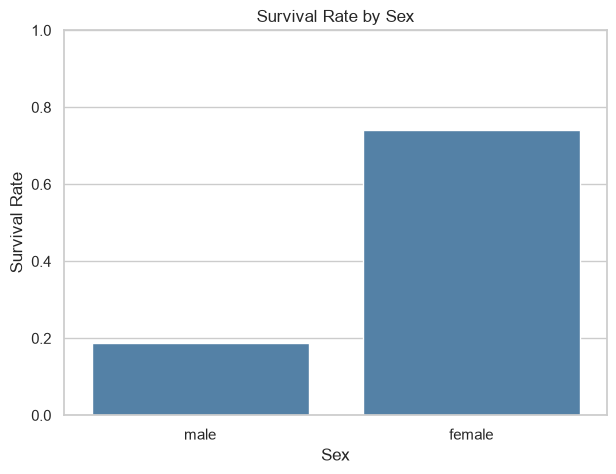

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.figure(figsize=(7, 5))
sns.barplot(data=df, x='Sex', y='Survived', errorbar=None, color='steelblue')
plt.title('Survival Rate by Sex')
plt.ylabel('Survival Rate')
plt.ylim(0, 1)
plt.show()

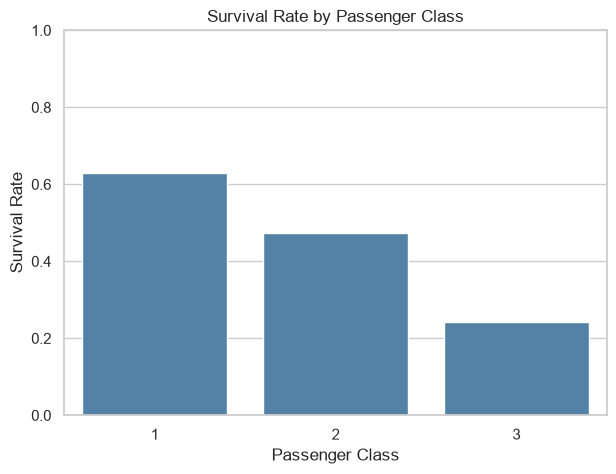

In [5]:
plt.figure(figsize=(7, 5))
sns.barplot(data=df, x='Pclass', y='Survived', errorbar=None, color='steelblue')
plt.title('Survival Rate by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate')
plt.ylim(0, 1)
plt.show()

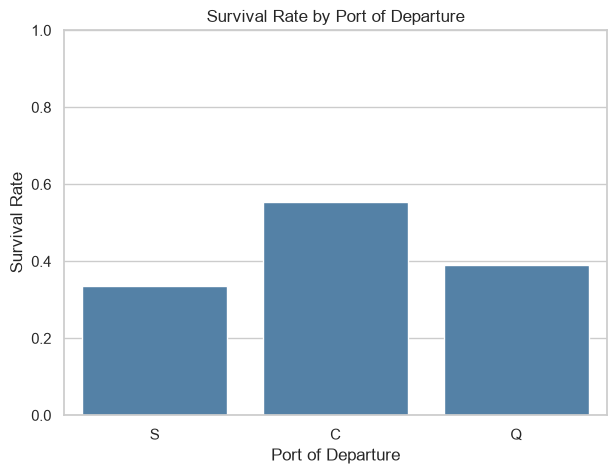

In [7]:
plt.figure(figsize=(7, 5))
sns.barplot(data=df, x='Embarked', y='Survived', errorbar=None, color='steelblue')
plt.title('Survival Rate by Port of Departure')
plt.xlabel('Port of Departure')
plt.ylabel('Survival Rate')
plt.ylim(0, 1)
plt.show()

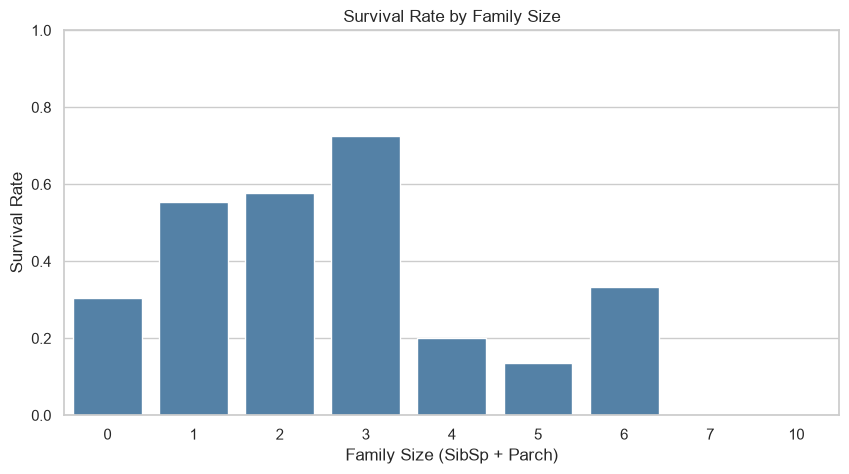

In [9]:
df['FamilySize'] = df['SibSp'] + df['Parch']

plt.figure(figsize=(10, 5))
sns.barplot(data=df, x='FamilySize', y='Survived', errorbar=None, color='steelblue')
plt.title('Survival Rate by Family Size')
plt.xlabel('Family Size (SibSp + Parch)')
plt.ylabel('Survival Rate')
plt.ylim(0, 1)
plt.show()

In [10]:
df['AgeGroup'] = 'Unknown'

df.loc[df['Age'] < 18, 'AgeGroup'] = 'Child'
df.loc[(df['Age'] >= 18) & (df['Age'] < 35), 'AgeGroup'] = 'Young Adult'
df.loc[(df['Age'] >= 35) & (df['Age'] < 60), 'AgeGroup'] = 'Adult'
df.loc[df['Age'] >= 60, 'AgeGroup'] = 'Senior'

print(df['AgeGroup'].value_counts())

AgeGroup
Young Adult    366
Adult          209
Unknown        177
Child          113
Senior          26
Name: count, dtype: int64


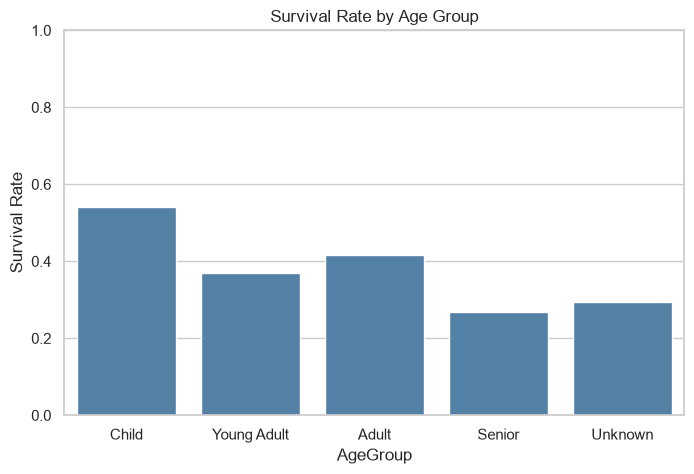

In [11]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='AgeGroup', y='Survived', errorbar=None, 
            order=['Child', 'Young Adult', 'Adult', 'Senior', 'Unknown'], color='steelblue')
plt.title('Survival Rate by Age Group')
plt.ylabel('Survival Rate')
plt.ylim(0, 1)
plt.show()

In [12]:
df['FareGroup'] = 'Unknown'

df.loc[df['Fare'] <= 7.91, 'FareGroup'] = 'Low'
df.loc[(df['Fare'] > 7.91) & (df['Fare'] <= 14.45), 'FareGroup'] = 'Medium-Low'
df.loc[(df['Fare'] > 14.45) & (df['Fare'] <= 31), 'FareGroup'] = 'Medium-High'
df.loc[df['Fare'] > 31, 'FareGroup'] = 'High'

print(df['FareGroup'].value_counts())

FareGroup
Medium-High    229
Low            223
High           222
Medium-Low     217
Name: count, dtype: int64


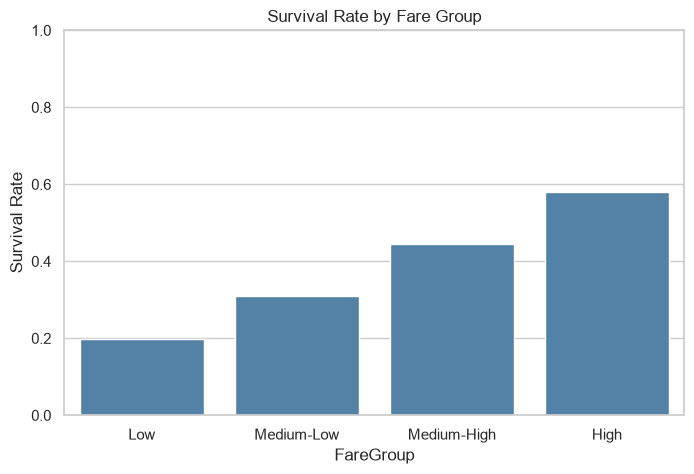

In [13]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='FareGroup', y='Survived', errorbar=None,
            order=['Low', 'Medium-Low', 'Medium-High', 'High'], color='steelblue')
plt.title('Survival Rate by Fare Group')
plt.ylabel('Survival Rate')
plt.ylim(0, 1)
plt.show()

In [ ]:
Most Likely to Survive Profile

Sex: Female
Passenger Class: 1st Class
Age: Child or Young Adult
Fare: High
Travel Companions: Small family (1–3 people)
Port of Embarkation: Cherbourg (C)

Evidence:
Females survived at ~74% vs males at ~19%. 1st class passengers survived at ~63%. Higher fares and Cherbourg embarkation also showed stronger survival rates. Children had the highest survival among age groups, and small families performed better than people traveling alone or in large groups.

In [ ]:
Least Likely to Survive Profile

Sex: Male
Passenger Class: 3rd Class
Age: Adult or Senior
Fare: Low
Travel Companions: Alone (FamilySize = 0) or very large family
Port of Embarkation: Southampton (S)

Evidence:
Males had a survival rate of only ~19%. 3rd class passengers survived at just ~24%. Low fare passengers and those who embarked at Southampton also had lower survival. Traveling alone or in large groups was associated with worse outcomes.

In [14]:
most_likely = df[
    (df['Sex'] == 'female') &
    (df['Pclass'] == 1) &
    (df['Embarked'] == 'C') &
    (df['FareGroup'] == 'High') &
    (df['FamilySize'].between(1, 3)) &
    (df['AgeGroup'].isin(['Child', 'Young Adult']))
]

most_likely[['Name', 'Sex', 'Age', 'Pclass', 'Fare', 'Embarked', 'FamilySize', 'Survived']]

,Name,Sex,Age,Pclass,Fare,Embarked,FamilySize,Survived
215,"Newell, Miss. Madeleine",female,31.0,1,113.2750,C,1,1
291,"Bishop, Mrs. Dickinson H (Helen Walton)",female,19.0,1,91.0792,C,1,1
307,"Penasco y Castellana, Mrs. Victor de Satode (M...",female,17.0,1,108.9000,C,1,1
329,"Hippach, Miss. Jean Gertrude",female,16.0,1,57.9792,C,1,1
393,"Newell, Miss. Marjorie",female,23.0,1,113.2750,C,1,1
539,"Frolicher, Miss. Hedwig Margaritha",female,22.0,1,49.5000,C,2,1
700,"Astor, Mrs. John Jacob (Madeleine Talmadge Force)",female,18.0,1,227.5250,C,1,1


In [15]:
least_likely = df[
    (df['Sex'] == 'male') &
    (df['Pclass'] == 3) &
    (df['Embarked'] == 'S') &
    (df['FareGroup'] == 'Low') &
    (df['FamilySize'] == 0) &
    (df['AgeGroup'].isin(['Adult', 'Senior']))
]

least_likely[['Name', 'Sex', 'Age', 'Pclass', 'Fare', 'Embarked', 'FamilySize', 'Survived']]

,Name,Sex,Age,Pclass,Fare,Embarked,FamilySize,Survived
94,"Coxon, Mr. Daniel",male,59.0,3,7.2500,S,0,0
108,"Rekic, Mr. Tido",male,38.0,3,7.8958,S,0,0
129,"Ekstrom, Mr. Johan",male,45.0,3,6.9750,S,0,0
179,"Leonard, Mr. Lionel",male,36.0,3,0.0000,S,0,0
189,"Turcin, Mr. Stjepan",male,36.0,3,7.8958,S,0,0
326,"Nysveen, Mr. Johan Hansen",male,61.0,3,6.2375,S,0,0
363,"Asim, Mr. Adola",male,35.0,3,7.0500,S,0,0
406,"Widegren, Mr. Carl/Charles Peter",male,51.0,3,7.7500,S,0,0
465,"Goncalves, Mr. Manuel Estanslas",male,38.0,3,7.0500,S,0,0
561,"Sivic, Mr. Husein",male,40.0,3,7.8958,S,0,0


In [ ]:
Newell, Miss. Madeleine - She was returning from a trip to the Middle East with her father and her sister, Marjorie Newell. They boarded the Titanic at Cherbourg. The two sisters occupied cabin D-36, their father was in D-48.

In [ ]:
Coxon, Mr. Daniel - Coxon was never married, apparently always living alone, and the 1900 census describes him as a labourer; by the time of the 1910 census, he was described as a street popcorn vendor.